In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# Signal functions
# ==================================================

def spatial_grid(L, Nx):
    return np.linspace(-L / 2, L / 2, Nx, endpoint=False)


def gaussian_thickness_profile(x, d0, h, sigma, x0=0):
    return d0 + h * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))


def phase_signal(d, n, lam):
    k = 2 * np.pi / lam
    return n * k * d


def phi_from_f(f):
    alpha = np.sum(f)

    phi = np.sqrt(f / alpha)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    return phi, alpha


def plot_signal(x, f, n_qubits):
    plt.figure(figsize=(7, 4))

    plt.plot(x * 1e6, f)

    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title(f"Gaussian Phase Signal ({n_qubits} qubits)")

    plt.grid(True)
    plt.tight_layout()



    plt.show()



def dense_state_to_quimb_mps(psi, n_qubits, cutoff=1e-3, max_bond=None):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)

    psi_tensor = psi.reshape([2] * n_qubits)

    qmps = qtn.MatrixProductState.from_dense(
        psi_tensor,
        dims=[2] * n_qubits,
        cutoff=cutoff,
        max_bond=max_bond,
    )

    return qmps


def quimb_bond_report(qmps):
    bond_sizes = []

    for i in range(qmps.L - 1):
        bond = qmps.bond(i, i + 1)
        bond_sizes.append(qmps.ind_size(bond))

    max_bond = max(bond_sizes) if len(bond_sizes) > 0 else 1

    return bond_sizes, max_bond


n_qubits: 8
Nx: 256
alpha: 127.99675641225457
psi shape: (256,)
psi norm: 1.0
min psi: 0.0002409875815236627
max psi: 0.12483465781506499


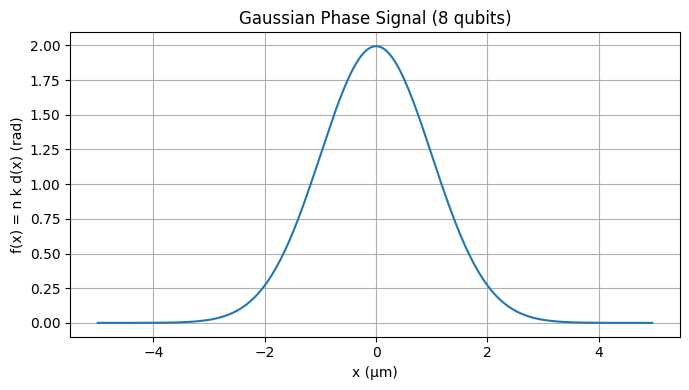

In [2]:
# ==================================================
# Parameters
# ==================================================

T = 10e-6

lam = 630e-9
n_refr = 1.0

d0 = 0.0
h = 200e-9
sigma = 1e-6
x0 = 0.0


# ==================================================
# Build psi for one chosen qubit number
# ==================================================

n_qubits = 8
Nx = 2 ** n_qubits

print("n_qubits:", n_qubits)
print("Nx:", Nx)

x = spatial_grid(T, Nx)

d = gaussian_thickness_profile(
    x=x,
    d0=d0,
    h=h,
    sigma=sigma,
    x0=x0
)

f = phase_signal(
    d=d,
    n=n_refr,
    lam=lam
)

psi, alpha = phi_from_f(f)

print("alpha:", alpha)
print("psi shape:", psi.shape)
print("psi norm:", np.linalg.norm(psi))
print("min psi:", np.min(np.abs(psi)))
print("max psi:", np.max(np.abs(psi)))

plot_signal(x, f, n_qubits)

In [8]:
from qiskit.quantum_info import Statevector
from qiskit_mps_initializer.datatypes import QuantumState
import quimb.tensor as qtn

# psi is already built previously
psi = np.asarray(psi, dtype=complex)
psi /= np.linalg.norm(psi)

target_state = Statevector(psi)

layer_list = range(1, 101)

layers = []
max_bond_chi_results = []
bond_profile_chi_results = []

circuit_depth_results = []
circuit_size_results = []

fidelity_zero_results = []
chi_statevector_results = []

zero_state = np.zeros_like(psi)
zero_state[0] = 1.0

for number_of_layers in layer_list:

    print("\n" + "=" * 70)
    print("number_of_layers =", number_of_layers)
    print("=" * 70)

    # --------------------------------------------------
    # Build preparation circuit
    # --------------------------------------------------

    psi_state = QuantumState.from_dense_data(
        data=psi,
        normalize=True,
    )

    U_psi = psi_state.generate_mps_initializer_circuit(
        number_of_layers=number_of_layers,
    )

    # --------------------------------------------------
    # Inverse circuit
    # --------------------------------------------------

    U_psi_dagger = U_psi.inverse()

    # --------------------------------------------------
    # χ = U† |ψ>
    # --------------------------------------------------

    chi_state = target_state.evolve(U_psi_dagger)

    chi = np.asarray(chi_state.data, dtype=complex)
    chi /= np.linalg.norm(chi)

    chi_statevector_results.append(chi) 

    # --------------------------------------------------
    # Convert χ into Quimb MPS
    # --------------------------------------------------

    qmps_chi = dense_state_to_quimb_mps(
        psi=chi,
        n_qubits=n_qubits,
        cutoff=1e-3,
        max_bond=None,
    )

    # --------------------------------------------------
    # Read bond dimensions
    # --------------------------------------------------

    bond_profile_chi, max_bond_chi = quimb_bond_report(qmps_chi)

    # --------------------------------------------------
    # Fidelity with |000...0>
    # --------------------------------------------------

    fidelity_zero = np.abs(np.vdot(zero_state, chi))**2

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    layers.append(number_of_layers)

    max_bond_chi_results.append(max_bond_chi)
    bond_profile_chi_results.append(bond_profile_chi)

    fidelity_zero_results.append(float(np.real(fidelity_zero)))

    circuit_depth_results.append(U_psi.depth())
    circuit_size_results.append(U_psi.size())

    # --------------------------------------------------
    # Print
    # --------------------------------------------------

    print("Bond profile of χ :", bond_profile_chi)
    print("Max bond dimension :", max_bond_chi)
    print("Fidelity with |000...0> :", fidelity_zero)
    print("Circuit depth :", U_psi.depth())
    print("Circuit size :", U_psi.size())


number_of_layers = 1
Bond profile of χ : [1, 1, 1, 1, 1, 1, 1]
Max bond dimension : 1
Fidelity with |000...0> : 0.9977474534073817
Circuit depth : 10
Circuit size : 16

number_of_layers = 2
Bond profile of χ : [1, 1, 1, 1, 1, 1, 1]
Max bond dimension : 1
Fidelity with |000...0> : 0.9971466207814792
Circuit depth : 12
Circuit size : 24

number_of_layers = 3
Bond profile of χ : [1, 1, 1, 1, 1, 1, 1]
Max bond dimension : 1
Fidelity with |000...0> : 0.9989093481114688
Circuit depth : 14
Circuit size : 32

number_of_layers = 4
Bond profile of χ : [1, 1, 1, 1, 1, 1, 1]
Max bond dimension : 1
Fidelity with |000...0> : 0.9990144778740024
Circuit depth : 16
Circuit size : 40

number_of_layers = 5
Bond profile of χ : [1, 1, 1, 1, 1, 1, 1]
Max bond dimension : 1
Fidelity with |000...0> : 0.9982489527690346
Circuit depth : 18
Circuit size : 48

number_of_layers = 6
Bond profile of χ : [1, 1, 1, 1, 1, 1, 1]
Max bond dimension : 1
Fidelity with |000...0> : 0.9974923430591366
Circuit depth : 20
Circ

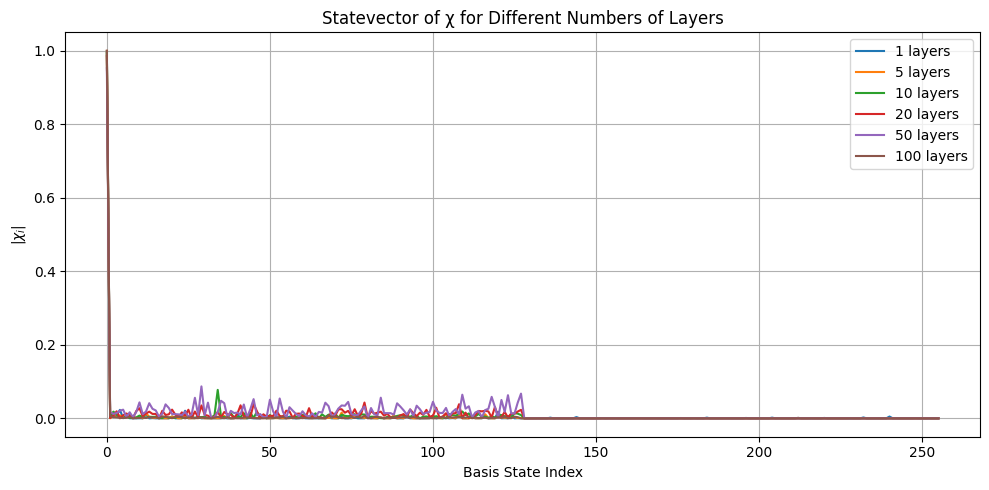

In [9]:
selected_layers = [1, 5, 10, 20, 50, 100]

plt.figure(figsize=(10,5))

for L in selected_layers:
    plt.plot(
        np.abs(chi_statevector_results[L-1]),
        label=f"{L} layers"
    )

plt.xlabel("Basis State Index")
plt.ylabel(r"$|\chi_i|$")
plt.title("Statevector of χ for Different Numbers of Layers")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

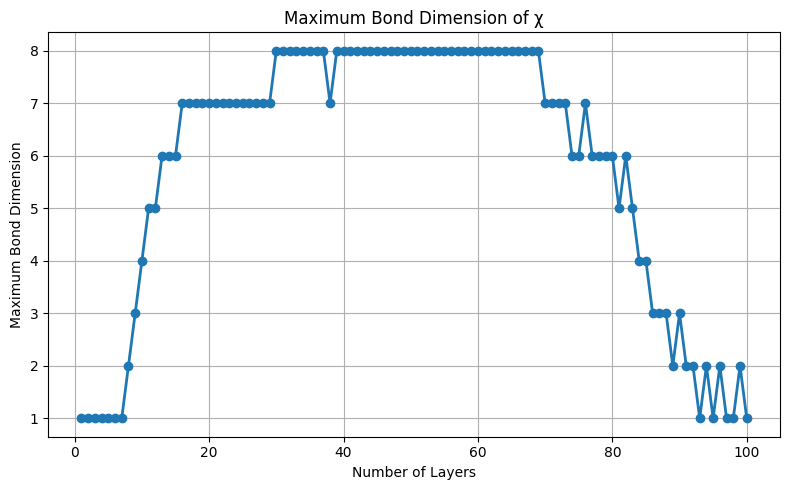

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    layers,
    max_bond_chi_results,
    "o-",
    linewidth=2,
)

plt.xlabel("Number of Layers")
plt.ylabel("Maximum Bond Dimension")
plt.title("Maximum Bond Dimension of χ")

plt.grid(True)

plt.tight_layout()
plt.show()

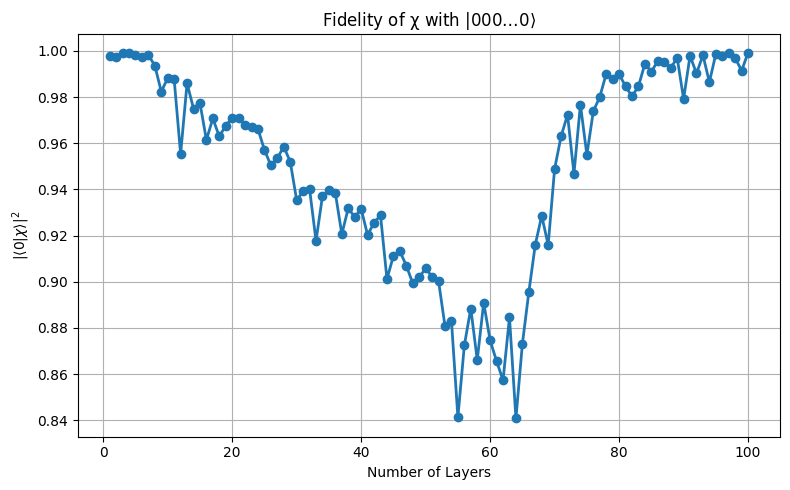

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    layers,
    fidelity_zero_results,
    "o-",
    linewidth=2,
)

plt.xlabel("Number of Layers")
plt.ylabel(r"$|\langle0|\chi\rangle|^2$")
plt.title("Fidelity of χ with $|000\\ldots0\\rangle$")

plt.grid(True)

plt.tight_layout()
plt.show()